In [9]:
#PACKAGES

#Load Key
import os
from dotenv import load_dotenv

load_dotenv()

assert os.getenv("GEMINI_API_KEY"), "API key not found"
print("API key loaded successfully")

#Initialize Gemini
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    temperature=0,
    google_api_key=os.getenv("GEMINI_API_KEY")
)

response = llm.invoke("Say hello")
print(response.content)

#LangGraph
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

API key loaded successfully
Hello there! How can I help you today?


In [10]:
#DOMAIN TOOLS

@tool
def drug_lookup(drug_name: str) -> str:
    """Look up clinical information about a medication.
    Args:
        drug_name: The name of the drug (brand or generic)
    """
    
    drugs = {
        "warfarin": "Warfarin — Anticoagulant. Uses: blood clot prevention, atrial fibrillation. Side effects: bleeding, bruising.",
        "metformin": "Metformin — Biguanide. Uses: type 2 diabetes, insulin resistance. Side effects: nausea, diarrhea.",
        "lisinopril": "Lisinopril — ACE inhibitor. Uses: hypertension, heart failure. Side effects: dry cough, dizziness.",
        "insulin": "Insulin — Insulin analogue. Uses: type 1 & 2 diabetes. Side effects: hypoglycemia, weight gain.",
        "aspirin": "Aspirin — NSAID/Antiplatelet. Uses: pain relief, heart attack prevention. Side effects: stomach irritation, bleeding."
    }
    
    return drugs.get(drug_name.lower().strip(), f"Drug '{drug_name}' not found.")

@tool
def drug_interaction_checker(drug_a: str, drug_b: str) -> str:
    """Check if two drugs have known interactions.
    Args:
        drug_a: First drug name
        drug_b: Second drug name
    """
    
    interactions = {
        ("warfarin", "aspirin"): "HIGH RISK — Both increase bleeding risk. Avoid combination or monitor closely.",
        ("metformin", "insulin"): "MODERATE — Can cause hypoglycemia. Adjust doses carefully.",
        ("lisinopril", "aspirin"): "LOW RISK — May slightly reduce ACE inhibitor effectiveness.",
    }
    
    key1 = (drug_a.lower().strip(), drug_b.lower().strip())
    key2 = (drug_b.lower().strip(), drug_a.lower().strip())
    
    return interactions.get(key1, interactions.get(key2, f"No known interaction between {drug_a} and {drug_b}."))

@tool
def symptom_checker(symptoms: str) -> str:
    """Check possible conditions based on symptoms.
    Args:
        symptoms: Comma-separated symptoms (e.g., 'chest pain, fatigue')
    """
    
    condition_map = {
        "chest pain": ["Myocardial Infarction (I21)", "Angina Pectoris (I20)", "GERD (K21)"],
        "shortness of breath": ["Asthma (J45)", "Heart Failure (I50)", "COPD (J44)"],
        "frequent urination": ["Type 2 Diabetes (E11)", "UTI (N39.0)"],
        "blurred vision": ["Diabetic Retinopathy (E11.3)", "Glaucoma (H40)"],
        "fatigue": ["Anemia (D64.9)", "Hypothyroidism (E03)", "Depression (F32)"],
        "headache": ["Tension Headache (G44.2)", "Migraine (G43)", "Hypertension (I10)"]
    }
    
    results = []
    for s in symptoms.split(","):
        s = s.strip().lower()
        if s in condition_map:
            results.extend(condition_map[s])
            
    return f"Possible conditions: {', '.join(results)}" if results else f"No matches for: {symptoms}"

@tool
def condition_info(condition: str) -> str:
    """Get information about a medical condition.
    Args:
        condition: The name of the condition
    """
    
    conditions = {
        "diabetes": "Diabetes Mellitus — Chronic metabolic disorder. Types: Type 1, Type 2, Gestational. Key marker: HbA1c > 6.5%.",
        "hypertension": "Hypertension — Chronic elevated blood pressure (>140/90 mmHg). Risk factor for stroke, MI, kidney disease.",
        "asthma": "Asthma — Chronic airway inflammation. Symptoms: wheezing, cough, chest tightness.",
        "copd": "COPD — Progressive lung disease. Includes emphysema and chronic bronchitis. Main cause: smoking.",
        "heart failure": "Heart Failure — Heart can't pump enough blood. Symptoms: fatigue, edema, shortness of breath."
    }
    
    return conditions.get(condition.lower().strip(), f"No info found for '{condition}'.")

@tool
def interpret_lab_result(test_name: str, value: float) -> str:
    """Interpret a specific lab result value.
    Args:
        test_name: Name of the lab test
        value: The numeric result value
    """
    
    if test_name.lower() == "glucose":
        if value < 70: return f"Glucose {value} mg/dL — LOW (hypoglycemia)."
        elif value <= 100: return f"Glucose {value} mg/dL — NORMAL."
        elif value <= 125: return f"Glucose {value} mg/dL — PRE-DIABETIC."
        else: return f"Glucose {value} mg/dL — DIABETIC RANGE."
    elif test_name.lower() == "hba1c":
        if value < 5.7: return f"HbA1c {value}% — NORMAL."
        elif value <= 6.4: return f"HbA1c {value}% — PRE-DIABETIC."
        else: return f"HbA1c {value}% — DIABETIC."
    elif test_name.lower() == "hemoglobin":
        if value < 12: return f"Hemoglobin {value} g/dL — LOW. Possible anemia."
        elif value <= 17.5: return f"Hemoglobin {value} g/dL — NORMAL."
        else: return f"Hemoglobin {value} g/dL — HIGH."
            
    return f"Cannot interpret {test_name} = {value}."

In [11]:
#HANDOFF TOOLS 

@tool
def handoff_to_medication(reason: str) -> str:
    """Hand off to the Medication Agent. Use this when the conversation
    needs medication expertise — drug info, interactions, side effects.
    Args:
        reason: Brief explanation of why you're handing off
    """
    
    return f"[Handoff to Medication Agent] Reason: {reason}"

@tool
def handoff_to_diagnosis(reason: str) -> str:
    """Hand off to the Diagnosis Agent. Use this when the conversation
    needs diagnosis expertise — symptoms, conditions, diseases.
    Args:
        reason: Brief explanation of why you're handing off
    """
    
    return f"[Handoff to Diagnosis Agent] Reason: {reason}"

@tool
def handoff_to_lab(reason: str) -> str:
    """Hand off to the Lab Agent. Use this when the conversation
    needs lab expertise — test interpretation, reference ranges.
    Args:
        reason: Brief explanation of why you're handing off
    """
    
    return f"[Handoff to Lab Agent] Reason: {reason}"

In [12]:
#AGENT DEFINITIONS

#State — tracks messages, current agent, and handoff count
class State(TypedDict):
    messages: Annotated[list, add_messages]
    current_agent: str
    handoff_count: int

#Triage only has handoff tools — it doesn't do any work itself
triage_tools = [handoff_to_medication, handoff_to_diagnosis, handoff_to_lab]
llm_triage = llm.bind_tools(triage_tools)

#Each specialist has its domain tools + handoff tools to pass to other specialists
medication_tools = [drug_lookup, drug_interaction_checker, handoff_to_diagnosis, handoff_to_lab]
llm_medication = llm.bind_tools(medication_tools)

diagnosis_tools = [symptom_checker, condition_info, handoff_to_medication, handoff_to_lab]
llm_diagnosis = llm.bind_tools(diagnosis_tools)

lab_tools = [interpret_lab_result, handoff_to_medication, handoff_to_diagnosis]
llm_lab = llm.bind_tools(lab_tools)

#Prompts
TRIAGE_PROMPT = """You are a triage agent at a hospital. Assess the patient's needs 
and hand off to the appropriate specialist. You MUST use one of your handoff tools.
- handoff_to_medication: for drug questions, prescriptions, side effects
- handoff_to_diagnosis: for symptoms, conditions, diseases
- handoff_to_lab: for lab test results and interpretation
Do NOT answer the question yourself. Just hand off."""

MEDICATION_PROMPT = """You are a medication specialist. Answer drug-related questions 
using your tools. Be concise and clinical.
IMPORTANT: If you don't have enough information to look up a specific drug, 
answer with what you know and suggest common medications for the condition.
Do NOT hand off back to a specialist that already provided findings.
Only hand off if there is a CLEAR need for another domain that hasn't been covered."""

DIAGNOSIS_PROMPT = """You are a diagnosis specialist. Identify conditions from symptoms 
using your tools. Be concise and clinical.
IMPORTANT: If you have already identified conditions, provide your answer.
Only hand off to medication if the user specifically asked about prescriptions 
and no medication specialist has responded yet.
Do NOT hand off back to a specialist that already provided findings."""

LAB_PROMPT = """You are a lab results specialist. Interpret lab values using your tools. 
Be concise and clinical.
IMPORTANT: If you have already interpreted the results, provide your answer.
Only hand off if there is a CLEAR need for another domain that hasn't been covered.
Do NOT hand off back to a specialist that already provided findings."""

#Message builder
def _build_messages(prompt, state, agent_name):
    """System prompt + original question + previous findings + this agent's recent tool history."""
    
    #Find original question
    question = "Help me."
    for msg in state["messages"]:
        if msg.type == "human":
            question = msg.content
            break
    
    #Find previous specialist answers
    previous = []
    for msg in state["messages"]:
        if msg.type == "ai" and msg.content and not (hasattr(msg, "tool_calls") and msg.tool_calls):
            previous.append(msg.content)
    
    if previous:
        question += "\n\nPrevious specialist findings:\n" + "\n".join(previous)
    
    messages = [SystemMessage(content=prompt), HumanMessage(content=question)]
    
    #Find this agent's recent tool calls and results
    recent_tool_msgs = []
    for msg in reversed(state["messages"]):
        if msg.type == "tool":
            recent_tool_msgs.insert(0, msg)
        elif msg.type == "ai" and hasattr(msg, "tool_calls") and msg.tool_calls:
            if not all(tc["name"].startswith("handoff_") for tc in msg.tool_calls):
                recent_tool_msgs.insert(0, msg)
            else:
                break
        else:
            break
    
    messages.extend(recent_tool_msgs)
    return messages

#Agents — each increments handoff_count when doing a handoff
def triage_agent(state: State):
    print(f"  🏥 Triage Agent assessing...")
    
    messages = [SystemMessage(content=TRIAGE_PROMPT)] + state["messages"]
    response = llm_triage.invoke(messages)
    
    return {"messages": [response], "current_agent": "triage", "handoff_count": 1}

def medication_agent(state: State):
    print(f"  💊 Medication Agent working...")
    
    messages = _build_messages(MEDICATION_PROMPT, state, "medication")
    response = llm_medication.invoke(messages)
    
    return {"messages": [response], "current_agent": "medication"}

def diagnosis_agent(state: State):
    print(f"  🩺 Diagnosis Agent working...")
    
    messages = _build_messages(DIAGNOSIS_PROMPT, state, "diagnosis")
    response = llm_diagnosis.invoke(messages)
    
    return {"messages": [response], "current_agent": "diagnosis"}

def lab_agent(state: State):
    print(f"  🔬 Lab Agent working...")
    
    messages = _build_messages(LAB_PROMPT, state, "lab")
    response = llm_lab.invoke(messages)
    
    return {"messages": [response], "current_agent": "lab"}

In [13]:
#ROUTING LOGIC

MAX_HANDOFFS = 3

def _count_handoffs(state: State):
    """Count how many handoffs have happened by looking at the message history."""
    count = 0
    
    for msg in state["messages"]:
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            for tc in msg.tool_calls:
                if tc["name"].startswith("handoff_"):
                    count += 1
    return count

def route_after_agent(state: State):
    """Check the last message: is it a handoff, a tool call, or a final answer?"""
    last = state["messages"][-1]
    
    #No tool calls — agent is done
    if not hasattr(last, "tool_calls") or not last.tool_calls:
        return "end"
    
    #Check if any tool call is a handoff
    for tc in last.tool_calls:
        if tc["name"].startswith("handoff_"):
            #Enforce handoff limit
            if _count_handoffs(state) >= MAX_HANDOFFS:
                print(f"  ⚠️ Handoff limit reached ({MAX_HANDOFFS}). Forcing answer.")
                return "end"
            
            if tc["name"] == "handoff_to_medication":
                return "handoff_medication"
            elif tc["name"] == "handoff_to_diagnosis":
                return "handoff_diagnosis"
            elif tc["name"] == "handoff_to_lab":
                return "handoff_lab"
    
    #Regular tool call
    return "use_tools"

#Tool nodes
triage_tool_node = ToolNode(tools=triage_tools)
medication_tool_node = ToolNode(tools=medication_tools)
diagnosis_tool_node = ToolNode(tools=diagnosis_tools)
lab_tool_node = ToolNode(tools=lab_tools)

def route_tools(state: State):
    """Route to the correct tool node based on current agent."""
    agent = state["current_agent"]
    if agent == "triage": return "triage_tools"
    elif agent == "medication": return "medication_tools"
    elif agent == "diagnosis": return "diagnosis_tools"
    elif agent == "lab": return "lab_tools"
    return "triage_tools"

def route_back(state: State):
    """After tools execute, go back to the current agent."""
    agent = state["current_agent"]
    if agent == "medication": return "medication_agent"
    elif agent == "diagnosis": return "diagnosis_agent"
    elif agent == "lab": return "lab_agent"
    return "triage"

Graph compiled!


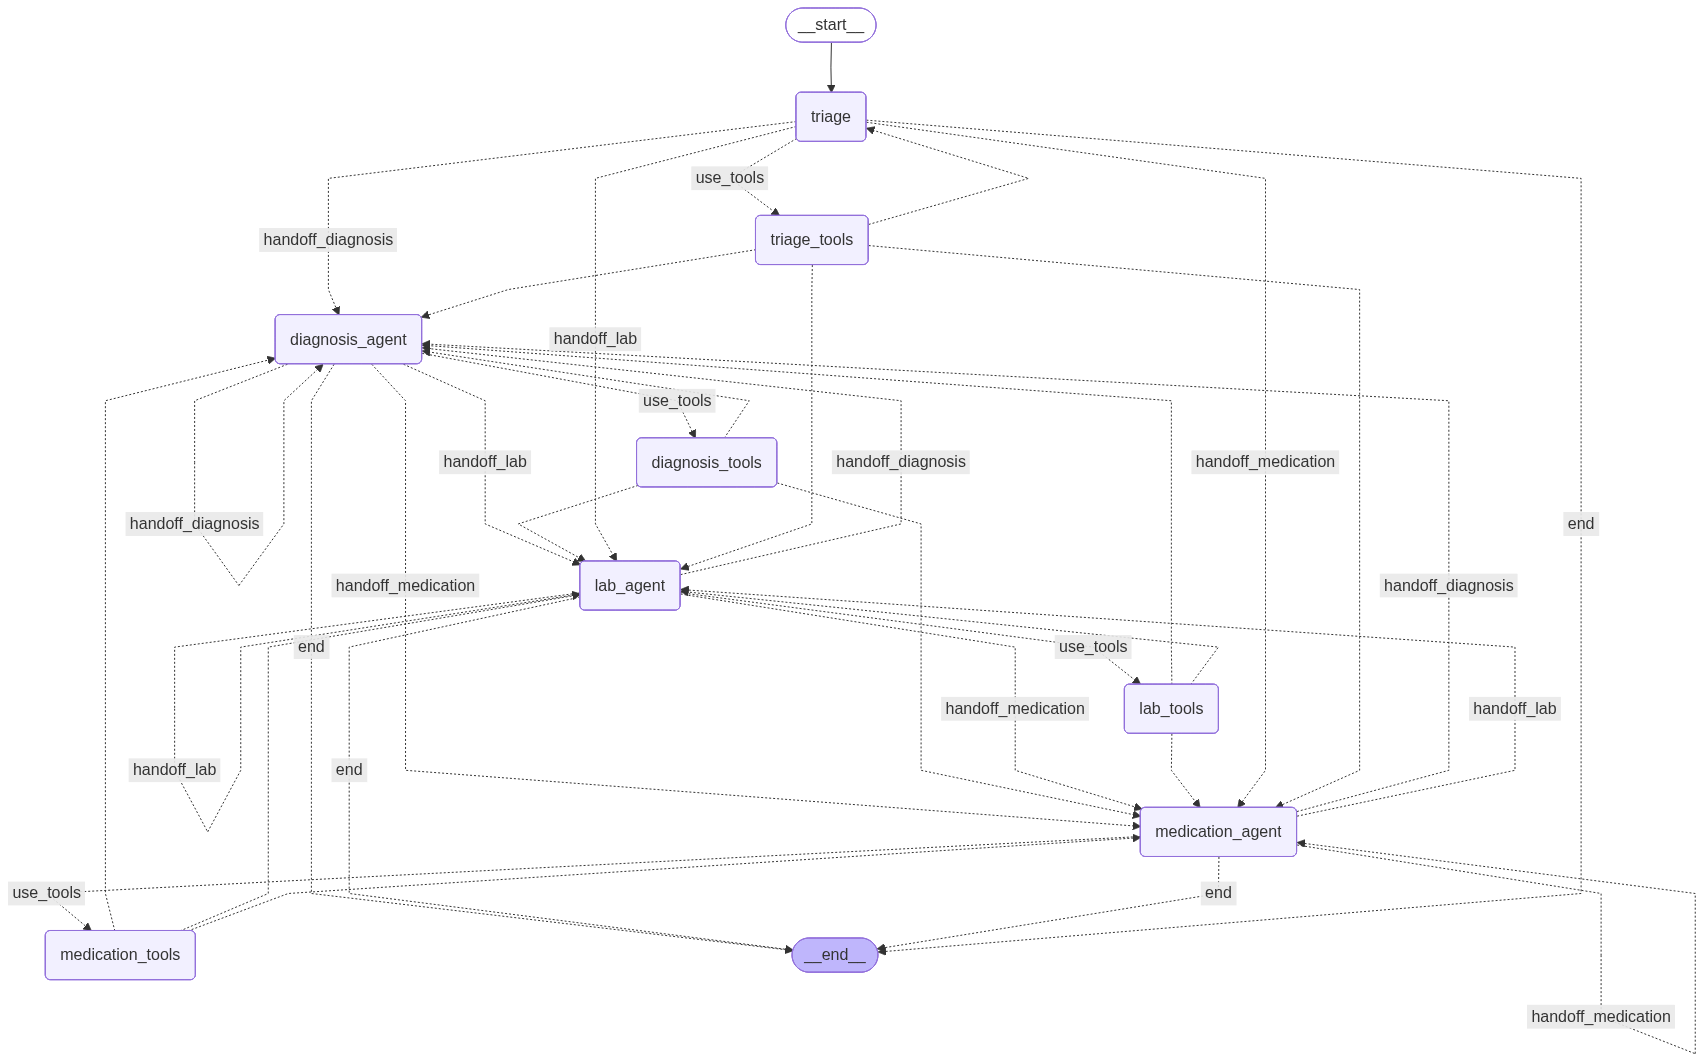

In [14]:
#BUILD, COMPILE AND VISUALIZE GRAPH

graph_builder = StateGraph(State)

#Nodes
graph_builder.add_node("triage", triage_agent)
graph_builder.add_node("medication_agent", medication_agent)
graph_builder.add_node("diagnosis_agent", diagnosis_agent)
graph_builder.add_node("lab_agent", lab_agent)
graph_builder.add_node("triage_tools", triage_tool_node)
graph_builder.add_node("medication_tools", medication_tool_node)
graph_builder.add_node("diagnosis_tools", diagnosis_tool_node)
graph_builder.add_node("lab_tools", lab_tool_node)

#Start → triage (always starts with triage)
graph_builder.add_edge(START, "triage")

#After triage: handoff or tool call
graph_builder.add_conditional_edges("triage", route_after_agent, {
    "handoff_medication": "medication_agent",
    "handoff_diagnosis": "diagnosis_agent",
    "handoff_lab": "lab_agent",
    "use_tools": "triage_tools",
    "end": END
})

#After medication agent: handoff, tools, or done
graph_builder.add_conditional_edges("medication_agent", route_after_agent, {
    "handoff_medication": "medication_agent",
    "handoff_diagnosis": "diagnosis_agent",
    "handoff_lab": "lab_agent",
    "use_tools": "medication_tools",
    "end": END
})

#After diagnosis agent: handoff, tools, or done
graph_builder.add_conditional_edges("diagnosis_agent", route_after_agent, {
    "handoff_medication": "medication_agent",
    "handoff_diagnosis": "diagnosis_agent",
    "handoff_lab": "lab_agent",
    "use_tools": "diagnosis_tools",
    "end": END
})

#After lab agent: handoff, tools, or done
graph_builder.add_conditional_edges("lab_agent", route_after_agent, {
    "handoff_medication": "medication_agent",
    "handoff_diagnosis": "diagnosis_agent",
    "handoff_lab": "lab_agent",
    "use_tools": "lab_tools",
    "end": END
})

#Tool results → back to current agent
graph_builder.add_conditional_edges("triage_tools", route_back, {
    "triage": "triage",
    "medication_agent": "medication_agent",
    "diagnosis_agent": "diagnosis_agent",
    "lab_agent": "lab_agent"
})
graph_builder.add_conditional_edges("medication_tools", route_back, {
    "medication_agent": "medication_agent",
    "diagnosis_agent": "diagnosis_agent",
    "lab_agent": "lab_agent"
})
graph_builder.add_conditional_edges("diagnosis_tools", route_back, {
    "medication_agent": "medication_agent",
    "diagnosis_agent": "diagnosis_agent",
    "lab_agent": "lab_agent"
})
graph_builder.add_conditional_edges("lab_tools", route_back, {
    "medication_agent": "medication_agent",
    "diagnosis_agent": "diagnosis_agent",
    "lab_agent": "lab_agent"
})

graph = graph_builder.compile()
print("Graph compiled!")

#Visualize
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

In [15]:
#RUN AGENT

def run_agent(question: str):
    print(f"\n{'='*60}")
    print(f"Question: {question}")
    print(f"{'='*60}")
    
    events = graph.stream(
        {"messages": [HumanMessage(content=question)]},
        stream_mode="values"
    )
    
    for event in events:
        last_msg = event["messages"][-1]
        if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
            for tc in last_msg.tool_calls:
                if tc["name"].startswith("handoff"):
                    print(f"  🔀 Handoff: {tc['name']}")
                else:
                    print(f"  🔧 Tool Call: {tc['name']}({tc['args']})")
        elif last_msg.type == "tool":
            content = last_msg.content[:300]
            if "Handing off" not in content:
                print(f"  📋 Tool Result: {content}")
        elif last_msg.type == "ai" and last_msg.content:
            print(f"  🤖 Response: {last_msg.content}")

In [16]:
#TESTS

run_agent("What are the side effects of aspirin?")
run_agent("My patient has shortness of breath and fatigue. What could it be?")
run_agent("My patient has chest pain. What could it be and what should I prescribe?")
run_agent("My patient's hemoglobin is 10 g/dL. What does that mean?")
run_agent("Patient has glucose of 180 and blurred vision. What's going on?")


Question: What are the side effects of aspirin?
  🏥 Triage Agent assessing...
  🔀 Handoff: handoff_to_medication
  💊 Medication Agent working...
  🔧 Tool Call: drug_lookup({'drug_name': 'aspirin'})
  📋 Tool Result: Aspirin — NSAID/Antiplatelet. Uses: pain relief, heart attack prevention. Side effects: stomach irritation, bleeding.
  💊 Medication Agent working...
  🤖 Response: Aspirin is an NSAID and antiplatelet drug used for pain relief and heart attack prevention. Common side effects include stomach irritation and bleeding.

Question: My patient has shortness of breath and fatigue. What could it be?
  🏥 Triage Agent assessing...
  🔀 Handoff: handoff_to_diagnosis
  🩺 Diagnosis Agent working...
  🔧 Tool Call: symptom_checker({'symptoms': 'shortness of breath, fatigue'})
  📋 Tool Result: Possible conditions: Asthma (J45), Heart Failure (I50), COPD (J44), Anemia (D64.9), Hypothyroidism (E03), Depression (F32)
  🩺 Diagnosis Agent working...
  🤖 Response: The patient's symptoms of shortne